In [17]:
import torch
import torchvision
import torchvision.transforms as transforms

In [18]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
batch_size = 4
trainset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified


/home/f/Documents/projects-local/learning_ai/tutorials/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


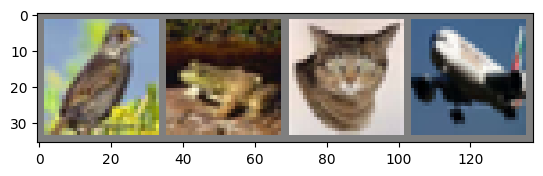

bird  frog  cat   plane


In [19]:
#display images
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img/2+0.5 #un-normalize
    npimg=img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))
    

In [20]:
#define convolutional neural net
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2) #what is this?
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

In [21]:
#loss fn and optimizer fn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)                      

In [22]:
#train network
for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        #split out inputs and labels
        inputs, labels = data
        #zero gradient
        optimizer.zero_grad()
        #forward pass, backward pass, optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #print statistics:
        running_loss += loss.item()
        if i%2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.182
[1,  4000] loss: 1.799
[1,  6000] loss: 1.632
[1,  8000] loss: 1.560
[1, 10000] loss: 1.499
[1, 12000] loss: 1.441
[2,  2000] loss: 1.374
[2,  4000] loss: 1.366
[2,  6000] loss: 1.324
[2,  8000] loss: 1.310
[2, 10000] loss: 1.286
[2, 12000] loss: 1.293
Finished Training


In [23]:
#save model
PATH='./cifar_net.pth'
torch.save(net.state_dict(), PATH)

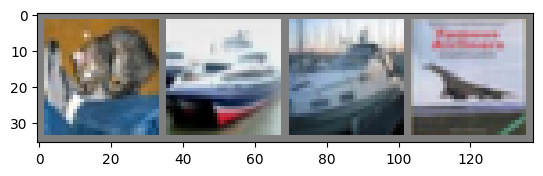

GroundTruth:  cat   ship  ship  plane


In [25]:
#test on test data
dataiter = iter(testloader)
images, labels = next(dataiter)

#print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [26]:
#load in saved model
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [35]:
outputs = net(images)

In [32]:
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))
for i in range(4):
    print(f'image {i} output energies:\n {outputs[i]}')

Predicted:  dog   dog   dog   ship 
image 0 output energies:
 tensor([-0.2643, -2.9035,  0.8204,  2.4651, -0.3699,  2.7304, -1.9792,  0.0586,
         0.3381, -2.8672], grad_fn=<SelectBackward0>)
image 1 output energies:
 tensor([-2.2454, -1.5090, -0.1409,  2.9220, -2.3438,  3.1053, -0.6792,  1.5281,
        -1.3728,  0.2933], grad_fn=<SelectBackward0>)
image 2 output energies:
 tensor([-2.5332, -4.2925,  0.7697,  3.5890,  2.3556,  3.7080,  0.7334,  1.7649,
        -3.7364, -3.9783], grad_fn=<SelectBackward0>)
image 3 output energies:
 tensor([ 3.3740, -1.2786,  1.0498, -1.0163,  0.0943, -2.1075, -1.3314, -3.1763,
         3.6876, -1.3767], grad_fn=<SelectBackward0>)


In [34]:
#test over whole test set
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 1000 test images: {100*correct//total} %')

Accuracy of the network on the 1000 test images: 55 %


In [37]:
#Analyze results that performed well vs poorly:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] +=1

for classname, correct_count in correct_pred.items():
    accuracy = 100*float(correct_count)/total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 43.9 %
Accuracy for class: car   is 71.1 %
Accuracy for class: bird  is 23.2 %
Accuracy for class: cat   is 44.0 %
Accuracy for class: deer  is 55.3 %
Accuracy for class: dog   is 48.3 %
Accuracy for class: frog  is 65.8 %
Accuracy for class: horse is 63.9 %
Accuracy for class: ship  is 76.0 %
Accuracy for class: truck is 66.8 %


In [39]:
#can transfer nn to GPU (like a tensor)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [40]:
net.to(device)
inputs, labels = data[0].to(device), data[1].to(device) #need to send inputs and targets to GPU as well

In [42]:
class Net2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 20, 5)
        self.pool = nn.MaxPool2d(2, 2) #what is this?
        self.conv2 = nn.Conv2d(20, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net2()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)     

#train network
for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        #split out inputs and labels
        inputs, labels = data
        #zero gradient
        optimizer.zero_grad()
        #forward pass, backward pass, optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #print statistics:
        running_loss += loss.item()
        if i%2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.188
[1,  4000] loss: 1.767
[1,  6000] loss: 1.605
[1,  8000] loss: 1.510
[1, 10000] loss: 1.444
[1, 12000] loss: 1.387
[2,  2000] loss: 1.305
[2,  4000] loss: 1.262
[2,  6000] loss: 1.260
[2,  8000] loss: 1.221
[2, 10000] loss: 1.191
[2, 12000] loss: 1.202
Finished Training


In [43]:
#test over whole test set
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 1000 test images: {100*correct//total} %')

Accuracy of the network on the 1000 test images: 59 %
